# Madrid Airbnb Price Analysis

This project analyzes Airbnb listings in Madrid to identify which neighborhoods have the highest average prices for entire home rentals.

The analysis focuses on cleaning the dataset, filtering comparable listings, and ensuring statistical reliability when comparing neighborhoods.

## Objective

The goal of this analysis is to identify the most expensive neighborhoods for Airbnb entire home rentals in Madrid.

To achieve this, the project:

- Cleans the dataset
- Filters listings to include only **entire homes**
- Removes missing values
- Aggregates prices by neighborhood
- Filters neighborhoods with small sample sizes
- Visualizes the top 10 most expensive areas

## Dataset

Source: **Inside Airbnb – Madrid listings dataset**

The dataset contains information about Airbnb listings, including:

- Neighborhood
- Price
- Room type
- Number of reviews
- Availability

This project focuses on analyzing **entire home listings** to ensure fair comparisons between properties.

## Import Libraries

We begin by importing the Python libraries used in the analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/listings.csv")

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250914152907,2025-09-15,previous scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,...,4.82,4.21,4.67,NaN,f,2,0,2,0,0.25
1,30320,https://www.airbnb.com/rooms/30320,20250914152907,2025-09-15,city scrape,Apartamentos Dana Sol,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409...,130907,...,4.78,4.90,4.69,NaN,t,17,17,0,0,0.93
2,30959,https://www.airbnb.com/rooms/30959,20250914152907,2025-09-15,previous scrape,Beautiful loft in Madrid Center,Beautiful Loft 60m2 size just in the historica...,NaN,https://a0.muscache.com/pictures/78173471/835e...,132883,...,4.63,4.88,4.25,NaN,f,1,1,0,0,0.06
3,40916,https://www.airbnb.com/rooms/40916,20250914152907,2025-09-15,city scrape,Apartasol Apartamentos Dana,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,130907,...,4.81,4.88,4.59,NaN,t,17,17,0,0,0.29
4,62423,https://www.airbnb.com/rooms/62423,20250914152907,2025-09-15,city scrape,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,DISTRICT WITH VERY GOOD VIBES IN THE MIDDLE OF...,https://a0.muscache.com/pictures/miso/Hosting-...,303845,...,4.86,4.97,4.60,NaN,f,3,1,2,0,2.78


In [3]:
df.shape

(25000, 79)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            25000 non-null  int64  
 1   listing_url                                   25000 non-null  object 
 2   scrape_id                                     25000 non-null  int64  
 3   last_scraped                                  25000 non-null  object 
 4   source                                        25000 non-null  object 
 5   name                                          25000 non-null  object 
 6   description                                   24130 non-null  object 
 7   neighborhood_overview                         10586 non-null  object 
 8   picture_url                                   24999 non-null  object 
 9   host_id                                       25000 non-null 

In [5]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.500000e+04,2.500000e+04,2.500000e+04,24903.000000,24903.000000,25000.000000,25000.000000,25000.000000,18960.000000,22488.000000,...,19852.000000,19852.000000,19853.000000,19850.000000,19849.000000,25000.000000,25000.000000,25000.000000,25000.000000,19853.000000
mean,7.248274e+17,2.025091e+13,2.806729e+08,63.174477,75.168454,40.422334,-3.693734,3.169920,1.310021,1.429340,...,4.667132,4.726252,4.728146,4.734457,4.533430,44.333840,37.792120,6.422280,0.087200,1.783268
std,5.719092e+17,0.000000e+00,2.200065e+08,153.447602,175.195381,0.023665,0.028232,1.921082,0.704779,0.969122,...,0.477303,0.463793,0.492312,0.399064,0.535482,93.334554,90.637266,26.726249,1.190014,2.081512
min,2.185300e+04,2.025091e+13,1.745300e+04,1.000000,1.000000,40.331400,-3.832060,1.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.974878e+07,2.025091e+13,6.184860e+07,1.000000,2.000000,40.409670,-3.707486,2.000000,1.000000,1.000000,...,4.580000,4.680000,4.700000,4.650000,4.430000,1.000000,0.000000,0.000000,0.000000,0.340000
50%,9.026240e+17,2.025091e+13,2.542674e+08,5.000000,7.000000,40.420827,-3.700850,3.000000,1.000000,1.000000,...,4.800000,4.850000,4.880000,4.860000,4.660000,4.000000,2.000000,0.000000,0.000000,1.090000
75%,1.237047e+18,2.025091e+13,4.690354e+08,34.000000,44.000000,40.432819,-3.684085,4.000000,1.500000,2.000000,...,4.940000,4.970000,4.990000,4.970000,4.830000,25.000000,18.000000,2.000000,0.000000,2.630000
max,1.508659e+18,2.025091e+13,7.184549e+08,1487.000000,2767.000000,40.535530,-3.545904,16.000000,19.000000,25.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,407.000000,407.000000,212.000000,29.000000,82.940000


In [6]:
columns = [
    "neighbourhood_cleansed",
    "room_type",
    "price",
    "number_of_reviews",
    "availability_365"
]

df = df[columns]

df.head()

,neighbourhood_cleansed,room_type,price,number_of_reviews,availability_365
0,Cármenes,Private room,NaN,33,198
1,Sol,Entire home/apt,$157.00,173,342
2,Embajadores,Entire home/apt,NaN,8,0
3,Universidad,Entire home/apt,$143.00,53,341
4,Justicia,Private room,$65.00,249,299


In [7]:
df.shape

(25000, 5)

## Data Cleaning

The dataset requires several preprocessing steps before analysis:

- Handling missing values
- Converting price values from strings to numeric format
- Filtering listings by room type
- Removing unreliable observations

These steps ensure the dataset is suitable for analysis.

In [32]:
df["price"] = df["price"].replace(r"[\$,]", "", regex=True).astype(float)

df.head()

,neighbourhood_cleansed,room_type,price,number_of_reviews,availability_365
0,Cármenes,Private room,NaN,33,198
1,Sol,Entire home/apt,157.0,173,342
2,Embajadores,Entire home/apt,NaN,8,0
3,Universidad,Entire home/apt,143.0,53,341
4,Justicia,Private room,65.0,249,299


In [9]:
df.dtypes

neighbourhood_cleansed     object
room_type                  object
price                     float64
number_of_reviews           int64
availability_365            int64
dtype: object

In [10]:
neigh_prices = df.groupby("neighbourhood_cleansed")["price"].mean()

neigh_prices.head()

neighbourhood_cleansed
Abrantes       54.447368
Acacias       103.862500
Adelfas       120.785047
Aeropuerto     93.500000
Aguilas        63.075000
Name: price, dtype: float64

In [11]:
neigh_prices = df.groupby("neighbourhood_cleansed")["price"].mean().sort_values(ascending=False)

neigh_prices.head(10)

neighbourhood_cleansed
Palomeras Bajas    590.292683
Fuentelareina      375.800000
Castillejos        326.032110
Piovera            301.769231
Valdefuentes       234.590164
Sol                233.745471
Recoletos          228.646388
Ibiza              227.782222
Jerónimos          217.988372
Palacio            210.255219
Name: price, dtype: float64

In [12]:
neigh_prices = neigh_prices.round(2)

neigh_prices.head(10)

neighbourhood_cleansed
Palomeras Bajas    590.29
Fuentelareina      375.80
Castillejos        326.03
Piovera            301.77
Valdefuentes       234.59
Sol                233.75
Recoletos          228.65
Ibiza              227.78
Jerónimos          217.99
Palacio            210.26
Name: price, dtype: float64

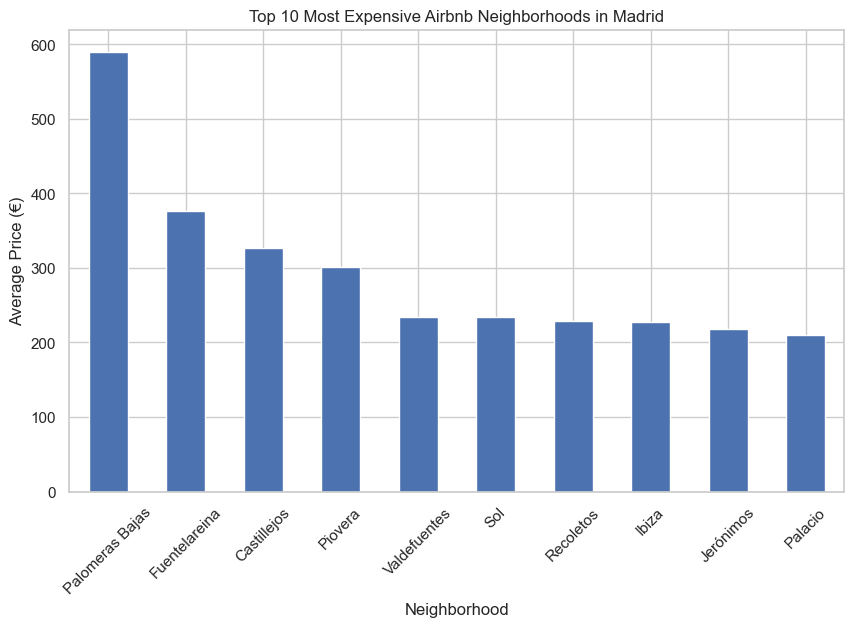

In [13]:
plt.figure(figsize=(10,6))

neigh_prices.head(10).plot(kind="bar")

plt.title("Top 10 Most Expensive Airbnb Neighborhoods in Madrid")
plt.ylabel("Average Price (€)")
plt.xlabel("Neighborhood")

plt.xticks(rotation=45)

plt.show()

In [14]:
neigh_prices.head(10).index

Index(['Palomeras Bajas', 'Fuentelareina', 'Castillejos', 'Piovera',
       'Valdefuentes', 'Sol', 'Recoletos', 'Ibiza', 'Jerónimos', 'Palacio'],
      dtype='object', name='neighbourhood_cleansed')

In [15]:
neigh_prices.head(10).values

array([590.29, 375.8 , 326.03, 301.77, 234.59, 233.75, 228.65, 227.78,
       217.99, 210.26])

In [16]:
neigh_counts = df["neighbourhood_cleansed"].value_counts()

neigh_counts.head(10)

neighbourhood_cleansed
Embajadores        2624
Universidad        2170
Palacio            1859
Sol                1293
Justicia           1227
Cortes             1057
Trafalgar           488
Cuatro Caminos      478
Palos de Moguer     408
Goya                404
Name: count, dtype: int64

In [17]:
analysis = pd.DataFrame({
    "average_price": neigh_prices,
    "number_of_listings": neigh_counts
})

analysis.head(10)

,average_price,number_of_listings
neighbourhood_cleansed,,
Abrantes,54.45,51
Acacias,103.86,241
Adelfas,120.79,134
Aeropuerto,93.50,13
Aguilas,63.08,57
Alameda de Osuna,75.40,30
Almagro,153.40,260
Almenara,118.85,198
Almendrales,126.80,121


In [18]:
analysis_filtered = analysis[analysis["number_of_listings"] > 30]

analysis_filtered.head(10)

,average_price,number_of_listings
neighbourhood_cleansed,,
Abrantes,54.45,51
Acacias,103.86,241
Adelfas,120.79,134
Aguilas,63.08,57
Almagro,153.40,260
Almenara,118.85,198
Almendrales,126.80,121
Aluche,64.67,88
Apostol Santiago,76.97,41


In [19]:
analysis_filtered = analysis_filtered.sort_values("average_price", ascending=False)

analysis_filtered.head(10)

,average_price,number_of_listings
neighbourhood_cleansed,,
Palomeras Bajas,590.29,59
Castillejos,326.03,290
Piovera,301.77,37
Valdefuentes,234.59,150
Sol,233.75,1293
Recoletos,228.65,320
Ibiza,227.78,284
Jerónimos,217.99,100
Palacio,210.26,1859


In [20]:
df_entire = df[df["room_type"] == "Entire home/apt"]

df_entire.head()

,neighbourhood_cleansed,room_type,price,number_of_reviews,availability_365
1,Sol,Entire home/apt,157.0,173,342
2,Embajadores,Entire home/apt,NaN,8,0
3,Universidad,Entire home/apt,143.0,53,341
5,Universidad,Entire home/apt,NaN,64,0
6,Universidad,Entire home/apt,116.0,36,305


In [21]:
df_entire = df_entire.dropna(subset=["price"])

df_entire.head()

,neighbourhood_cleansed,room_type,price,number_of_reviews,availability_365
1,Sol,Entire home/apt,157.0,173,342
3,Universidad,Entire home/apt,143.0,53,341
6,Universidad,Entire home/apt,116.0,36,305
7,Universidad,Entire home/apt,79.0,31,317
8,Embajadores,Entire home/apt,300.0,133,180


In [22]:
df_entire = df_entire.dropna(subset=["price"])

df_entire.head(10)

,neighbourhood_cleansed,room_type,price,number_of_reviews,availability_365
1,Sol,Entire home/apt,157.0,173,342
3,Universidad,Entire home/apt,143.0,53,341
6,Universidad,Entire home/apt,116.0,36,305
7,Universidad,Entire home/apt,79.0,31,317
8,Embajadores,Entire home/apt,300.0,133,180
11,Embajadores,Entire home/apt,166.0,233,150
21,Cortes,Entire home/apt,160.0,107,43
22,Universidad,Entire home/apt,98.0,374,319
24,Embajadores,Entire home/apt,117.0,79,42
26,Embajadores,Entire home/apt,58.0,563,291


In [23]:
avg_price_entire = df_entire.groupby("neighbourhood_cleansed")["price"].mean()

avg_price_entire.head()

neighbourhood_cleansed
Abrantes       81.714286
Acacias       122.935780
Adelfas       129.329545
Aeropuerto    187.333333
Aguilas       105.285714
Name: price, dtype: float64

In [24]:
avg_price_entire = avg_price_entire.round(2)

avg_price_entire.head()

neighbourhood_cleansed
Abrantes       81.71
Acacias       122.94
Adelfas       129.33
Aeropuerto    187.33
Aguilas       105.29
Name: price, dtype: float64

In [25]:
count_entire = df_entire["neighbourhood_cleansed"].value_counts()

count_entire.head()

neighbourhood_cleansed
Embajadores    1556
Universidad    1302
Palacio        1205
Sol             859
Justicia        765
Name: count, dtype: int64

In [26]:
final_analysis = pd.DataFrame({
    "average_price_entire_home": avg_price_entire,
    "number_of_entire_homes": count_entire
})

final_analysis.head(10)

,average_price_entire_home,number_of_entire_homes
neighbourhood_cleansed,,
Abrantes,81.71,7
Acacias,122.94,109
Adelfas,129.33,88
Aeropuerto,187.33,3
Aguilas,105.29,7
Alameda de Osuna,134.75,4
Almagro,184.45,126
Almenara,137.04,122
Almendrales,89.90,60


In [27]:
final_filtered = final_analysis[final_analysis["number_of_entire_homes"] > 100]

final_filtered.head(10)

,average_price_entire_home,number_of_entire_homes
neighbourhood_cleansed,,
Acacias,122.94,109
Almagro,184.45,126
Almenara,137.04,122
Arapiles,162.25,153
Argüelles,249.42,154
Bellas Vistas,125.40,116
Berruguete,118.76,147
Castellana,223.72,145
Castillejos,414.60,164


In [28]:
final_filtered = final_filtered.sort_values("average_price_entire_home", ascending=False)

final_filtered.head(10)

,average_price_entire_home,number_of_entire_homes
neighbourhood_cleansed,,
Castillejos,414.60,164
Ibiza,294.82,163
Puerta del Angel,287.22,125
Sol,261.98,859
Recoletos,253.01,226
Argüelles,249.42,154
Palacio,232.58,1205
Castellana,223.72,145
Imperial,211.91,102


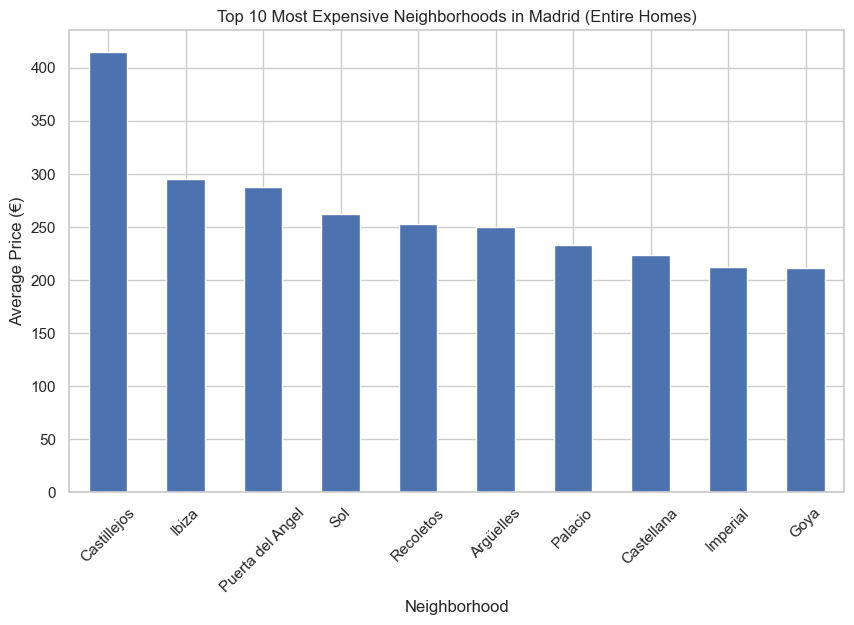

In [29]:
plt.figure(figsize=(10,6))

final_filtered.head(10)["average_price_entire_home"].plot(kind="bar")

plt.title("Top 10 Most Expensive Neighborhoods in Madrid (Entire Homes)")
plt.ylabel("Average Price (€)")
plt.xlabel("Neighborhood")

plt.xticks(rotation=45)

plt.show()

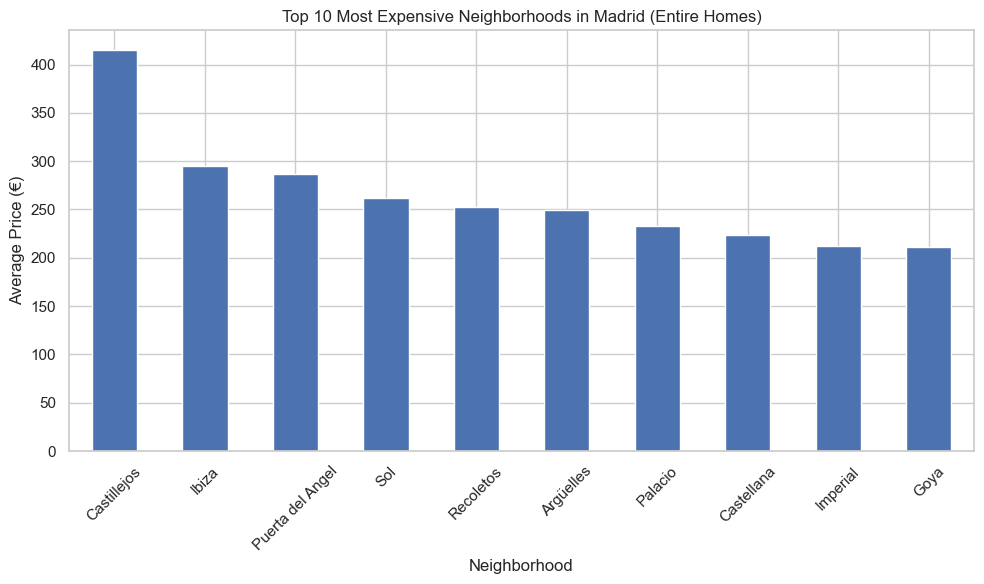

In [30]:
plt.figure(figsize=(10,6))

final_filtered.head(10)["average_price_entire_home"].plot(kind="bar")

plt.title("Top 10 Most Expensive Neighborhoods in Madrid (Entire Homes)")
plt.ylabel("Average Price (€)")
plt.xlabel("Neighborhood")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../top10_airbnb_prices_madrid.png")

plt.show()

## Top 10 Most Expensive Neighborhoods for Airbnb Entire Homes

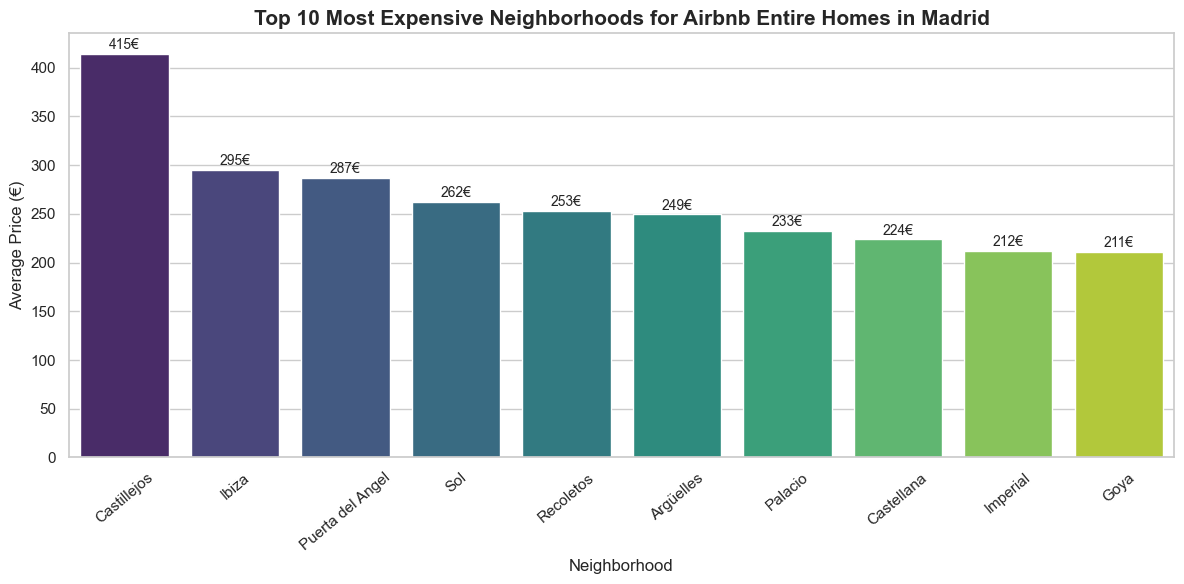

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

top10 = final_filtered.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top10.index,
    y=top10["average_price_entire_home"],
    hue=top10.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Most Expensive Neighborhoods for Airbnb Entire Homes in Madrid",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Neighborhood")
plt.ylabel("Average Price (€)")

plt.xticks(rotation=40)

# adicionar valores nas barras
for i, v in enumerate(top10["average_price_entire_home"]):
    ax.text(i, v + 5, f"{v:.0f}€", ha="center", fontsize=10)

plt.tight_layout()

plt.savefig(
    "../outputs/top10_airbnb_prices_madrid_linkedin.png",
    dpi=300
)

plt.show()

## Key Insights

- **Central neighborhoods dominate high Airbnb prices.** Areas such as Sol and Palacio combine high demand from tourists with a large number of listings.

- **Salamanca district appears among the most expensive areas.** Neighborhoods such as Recoletos, Goya, and Castellana show consistently high average prices for entire home rentals.

- **Sample size filtering improves reliability.** Restricting the analysis to neighborhoods with more than 100 listings helps reduce statistical noise from small samples.

- **Tourist-heavy areas show both high prices and high listing density**, suggesting strong demand for short-term rentals.

## Conclusion

This analysis explored Airbnb listings in Madrid to identify the most expensive neighborhoods for entire home rentals.

By cleaning the dataset, filtering comparable listings, and ensuring a sufficient sample size per neighborhood, the analysis provides a more reliable view of price patterns across the city.

Future improvements could include comparing Airbnb prices with long-term rental prices, analyzing price distributions (median vs mean), or building an interactive dashboard for deeper exploration.